# Adidas Revenue Forecasting using SARIMAX

## Introduction

Time series analysis is an important technique for understanding patterns, trends, and future behavior in data collected over time. In this notebook, we analyze Adidas quarterly sales revenue and apply time series methods to explore revenue trends and generate future predictions.

The project includes data loading, time-based visualization, seasonal decomposition, SARIMAX modeling, and revenue forecasting. The main goal is to understand how sales revenue changes over time and build a basic forecasting model for future periods.

In [1]:
import pandas as pd
from datetime import date, timedelta
import datetime
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm

In [2]:
df=pd.read_csv('/kaggle/input/datasets/nihalba/adidas-quarterly-sales-csv/adidas-quarterly-sales.csv')

In [3]:
df.head()

,Time Period,Revenue
0,2000Q1,1517
1,2000Q2,1248
2,2000Q3,1677
3,2000Q4,1393
4,2001Q1,1558


In [4]:
import plotly.express as px
import numpy as np

In [12]:
px.line(df,x="Time Period",y="Revenue")

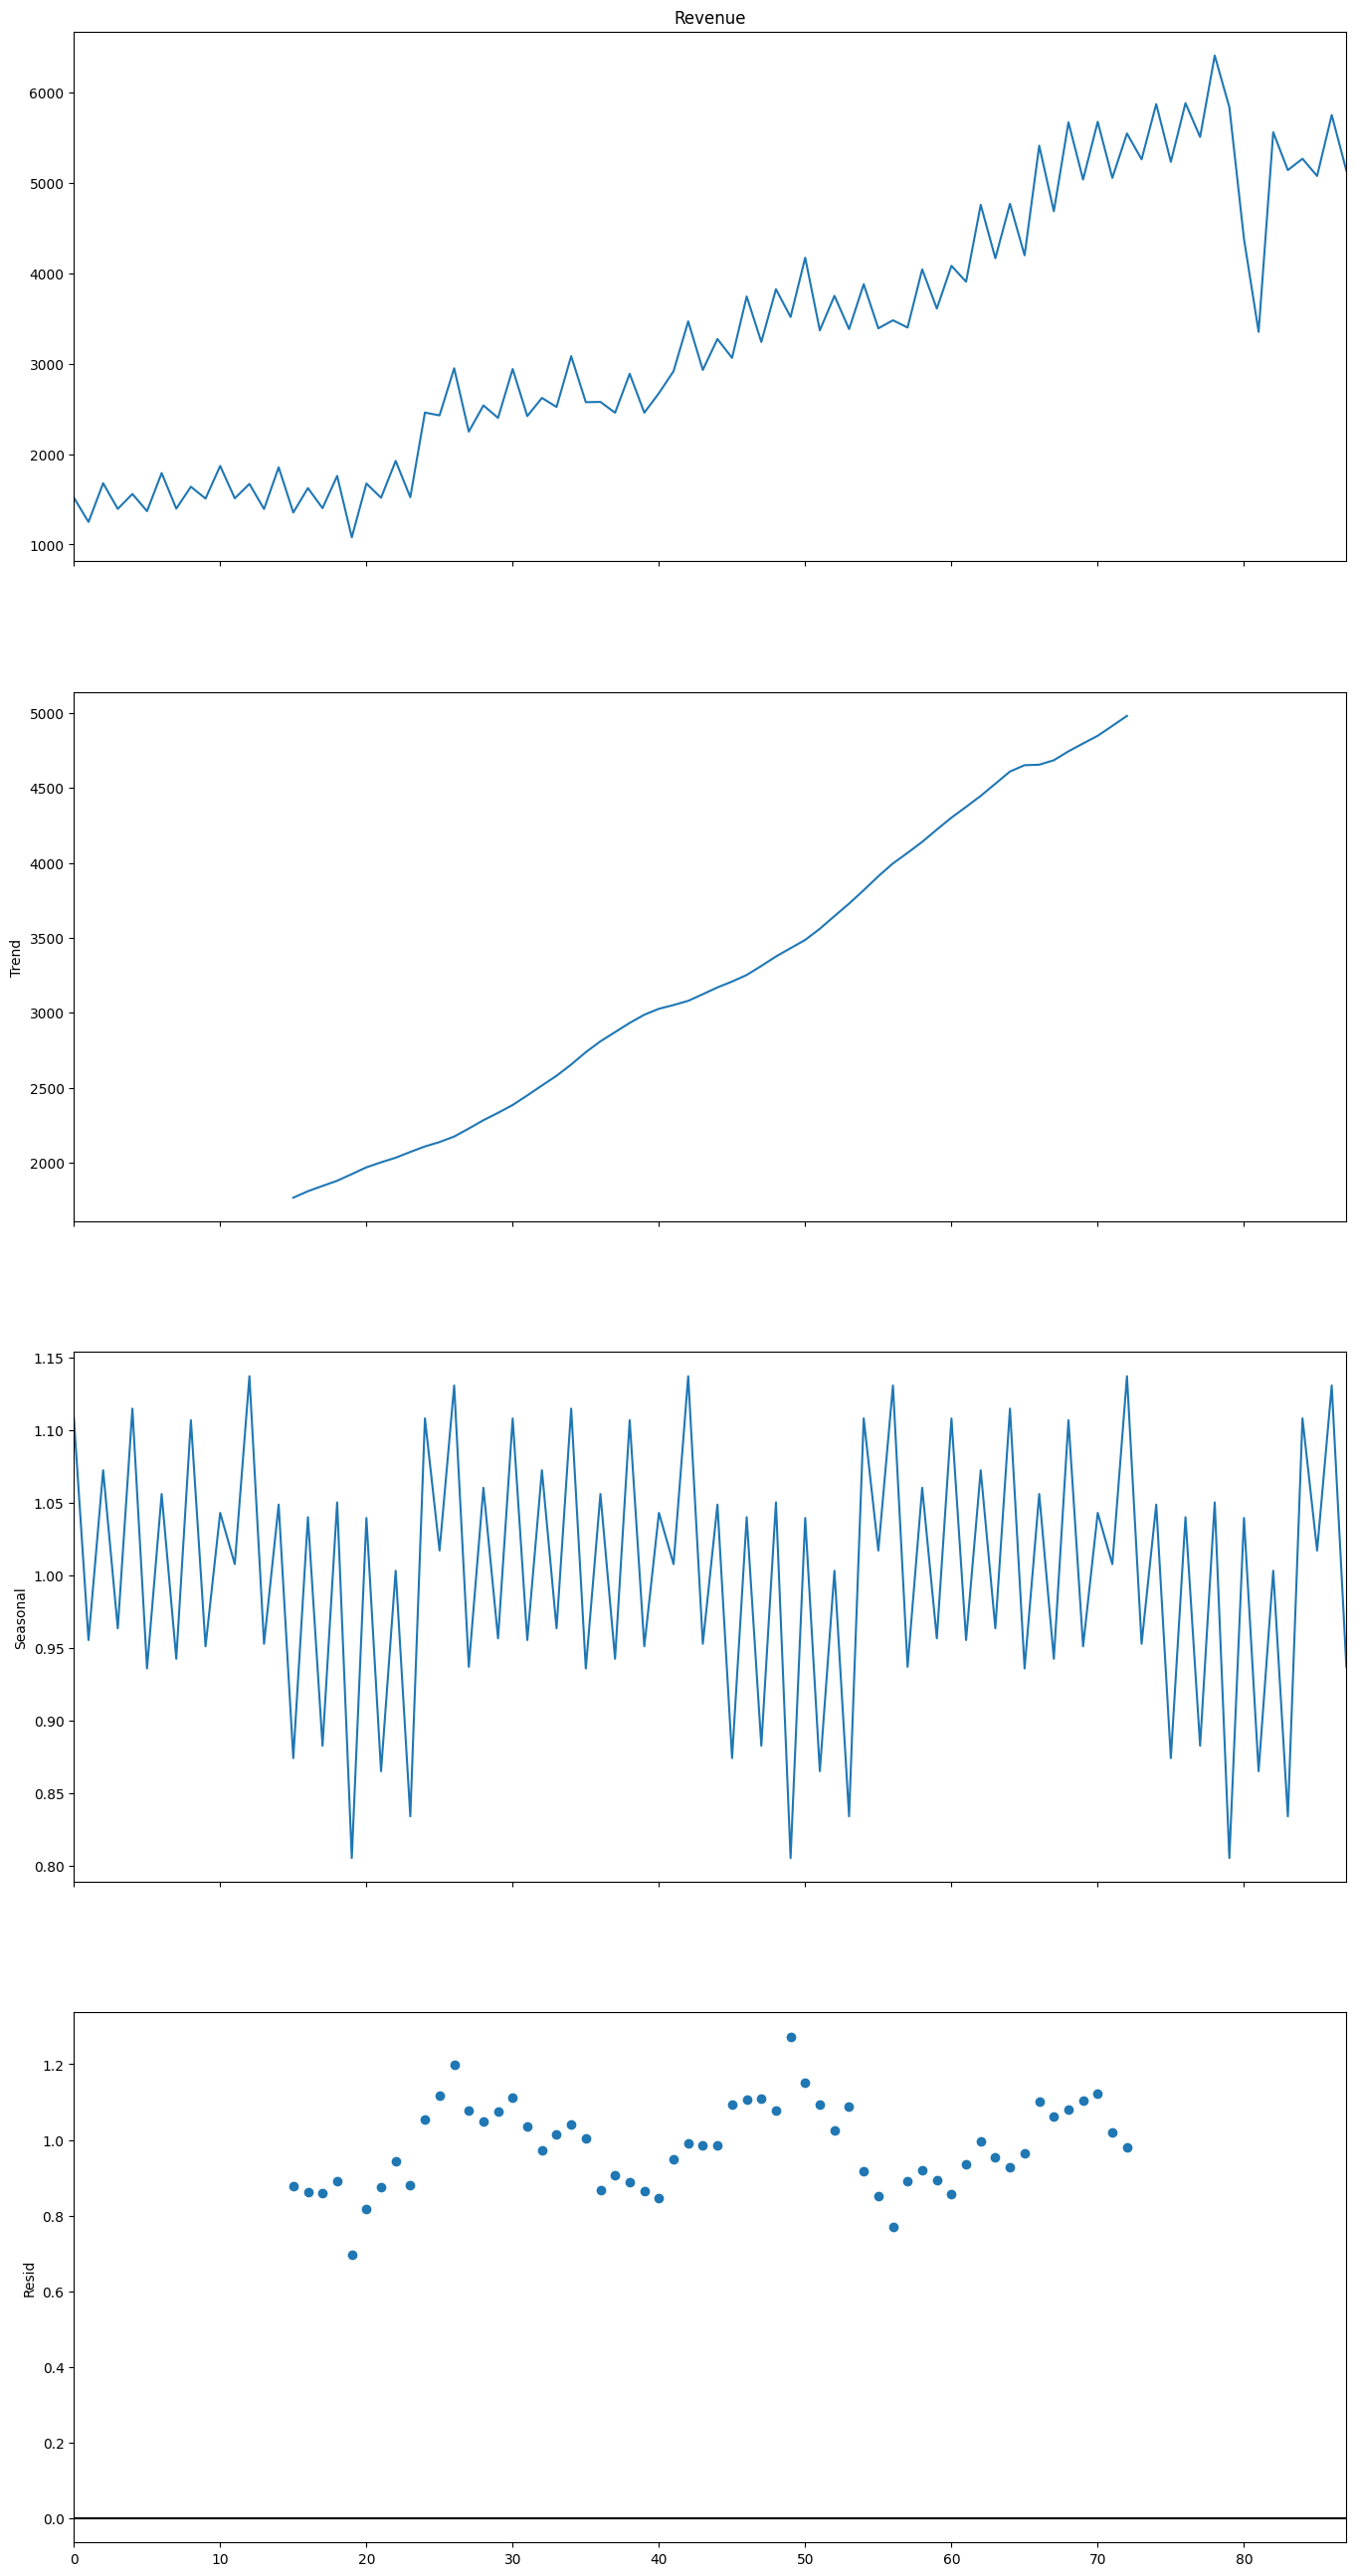

In [6]:
result=seasonal_decompose(df['Revenue'], model='multiplicative', period=30)
fig=result.plot()
fig.set_size_inches(15,30)

In [7]:
model=sm.tsa.statespace.SARIMAX(df['Revenue']) #sunumlarda ARIMA olarak geciyordu
result=model.fit()

In [8]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Revenue   No. Observations:                   88
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -685.939
Date:                Sat, 09 May 2026   AIC                           1375.877
Time:                        16:15:29   BIC                           1380.832
Sample:                             0   HQIC                          1377.874
                                 - 88                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9878      0.014     68.840      0.000       0.960       1.016
sigma2      3.324e+05   4.14e+04      8.028      0.000    2.51e+05    4.14e+05
===================================================================================
Ljung-Box (L1) (Q):                  33.98   Jarque-Bera (JB):                 7.84
Prob(Q):                              0.00   Prob(JB):                         0.02
Heteroskedasticity (H):               3.78   Skew:                             0.50
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
predictions=result.predict(len(df),len(df)+7)

In [10]:
predictions 

88    5074.368262
89    5012.500147
90    4951.386345
91    4891.017660
92    4831.385007
93    4772.479412
94    4714.292010
95    4656.814046
Name: predicted_mean, dtype: float64

<Axes: >

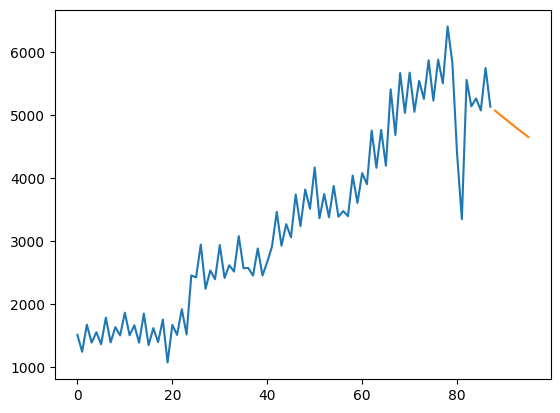

In [11]:
df['Revenue'].plot()
predictions.plot()

## Conclusion

In this notebook, Adidas quarterly sales revenue was analyzed using time series analysis techniques. The revenue trend was first visualized to understand overall movement, and seasonal decomposition was applied to examine underlying patterns in the data.

A SARIMAX model was then used to forecast future revenue values. The prediction results provide a basic view of how future sales may behave based on historical revenue patterns.

Overall, this notebook demonstrates the core workflow of a time series forecasting project, including visualization, decomposition, model training, and future prediction.